## 02 — Preprocessing PRDECT-ID: Indonesian Sentimen Classification

Dataset: [PRDECT-ID](https://www.kaggle.com/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification)

**Kolom yang digunakan:**
- Teks : `Customer Review`
- Label: `Sentimen` → 2 nilai: `Positive`, `Negative`

**Label mapping (5-class sentiment):**
- `positive`   → 0
- `negative`    → 1

**Pipeline:**
1. Load dataset
2. EDA: distribusi label, panjang teks
3. Text cleaning (lowercase, hapus noise)
4. Stratified split (80% train / 20% test) — tanpa augmentasi
5. Export CSV

In [1]:
## 0. Google Colab Setup
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages ...")
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_PROJECT = "/content/drive/MyDrive/xai_lime_vs_shap"

    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)
        print(f"CWD set to: {DRIVE_PROJECT}")
    else:
        print(f"WARNING: '{DRIVE_PROJECT}' not found. Please check your Drive path.")

    !pip install -q kaggle emoji
else:
    print("Local environment detected — skipping Colab setup.")

Google Colab detected — mounting Drive & installing packages ...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD set to: /content/drive/MyDrive/xai_lime_vs_shap


In [2]:
## 1. Imports & Config
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import unicodedata

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

def find_project_root() -> Path:
    markers = ["data", "notebooks", "src"]
    candidate = Path.cwd()
    for _ in range(3):
        if all((candidate / m).exists() for m in markers):
            return candidate
        candidate = candidate.parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
RAW_DIR     = PROJECT_ROOT / "data" / "raw"
PROC_DIR    = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

# PIVOT: Menggunakan kolom 'Sentiment' untuk klasifikasi biner (Positive vs Negative)
TEXT_COL  = "Customer Review"
LABEL_COL = "Sentiment"

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw dir      : {RAW_DIR}")
print(f"Processed    : {PROC_DIR}")
print(f"TEXT_COL     : {TEXT_COL}")
print(f"LABEL_COL    : {LABEL_COL}")

Project root : /content/drive/MyDrive/xai_lime_vs_shap
Raw dir      : /content/drive/MyDrive/xai_lime_vs_shap/data/raw
Processed    : /content/drive/MyDrive/xai_lime_vs_shap/data/processed
TEXT_COL     : Customer Review
LABEL_COL    : Sentiment


In [3]:
## 2. Download Dataset dari Kaggle (jika belum ada)
RAW_CSV = RAW_DIR / "PRDECT-ID Dataset.csv"

if not RAW_CSV.exists():
    print("Downloading PRDECT-ID dataset from Kaggle...")
    if IN_COLAB:
        !mkdir -p ~/.kaggle
        kaggle_json = Path("/content/drive/MyDrive/.kaggle/kaggle.json")
        if kaggle_json.exists():
            !cp {str(kaggle_json)} ~/.kaggle/kaggle.json
            !chmod 600 ~/.kaggle/kaggle.json
        os.chdir(str(RAW_DIR))
        !kaggle datasets download -d jocelyndumlao/prdect-id-indonesian-emotion-classification --unzip
        os.chdir(str(PROJECT_ROOT))
    else:
        print("Please download manually from:")
        print("https://www.kaggle.com/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification")
        print(f"Place the CSV in: {RAW_DIR}")
else:
    print(f"Dataset found: {RAW_CSV}")

Dataset found: /content/drive/MyDrive/xai_lime_vs_shap/data/raw/PRDECT-ID Dataset.csv


In [4]:
## 3. Load Dataset
csv_files    = list(RAW_DIR.glob("*.csv"))
prdect_files = [f for f in csv_files if "PRDECT" in f.name or "prdect" in f.name.lower()]

if not prdect_files:
    raise FileNotFoundError(f"PRDECT-ID CSV not found in {RAW_DIR}. Please download it first.")

RAW_CSV = prdect_files[0]
print(f"Loading: {RAW_CSV.name}")

df = pd.read_csv(RAW_CSV)
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")

Loading: PRDECT-ID Dataset.csv

Shape: (5400, 11)

Columns: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']

Dtypes:
Category            object
Product Name        object
Location            object
Price                int64
Overall Rating     float64
Number Sold          int64
Total Review         int64
Customer Rating      int64
Customer Review     object
Sentiment           object
Emotion             object
dtype: object


In [5]:
## 4. Validasi Kolom
for col in [TEXT_COL, LABEL_COL]:
    assert col in df.columns, f"Kolom '{col}' tidak ditemukan! Kolom yang ada: {list(df.columns)}"

print("=== Sample Data ===")
display(df[[TEXT_COL, LABEL_COL]].head(5))

print(f"\nJenis data '{TEXT_COL}': {df[TEXT_COL].dtype}")
print(f"Contoh teks: {df[TEXT_COL].iloc[0]}")
print(f"\nJenis data '{LABEL_COL}': {df[LABEL_COL].dtype}")
print(f"Nilai unik '{LABEL_COL}': {sorted(df[LABEL_COL].dropna().unique())}")

=== Sample Data ===


,Customer Review,Sentiment
0,Alhamdulillah berfungsi dengan baik. Packaging...,Positive
1,"barang bagus dan respon cepat, harga bersaing ...",Positive
2,"barang bagus, berfungsi dengan baik, seler ram...",Positive
3,bagus sesuai harapan penjual nya juga ramah. t...,Positive
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive



Jenis data 'Customer Review': object
Contoh teks: Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah

Jenis data 'Sentiment': object
Nilai unik 'Sentiment': ['Negative', 'Positive']


=== Distribusi Emosi ===
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Total: 5400 sampel


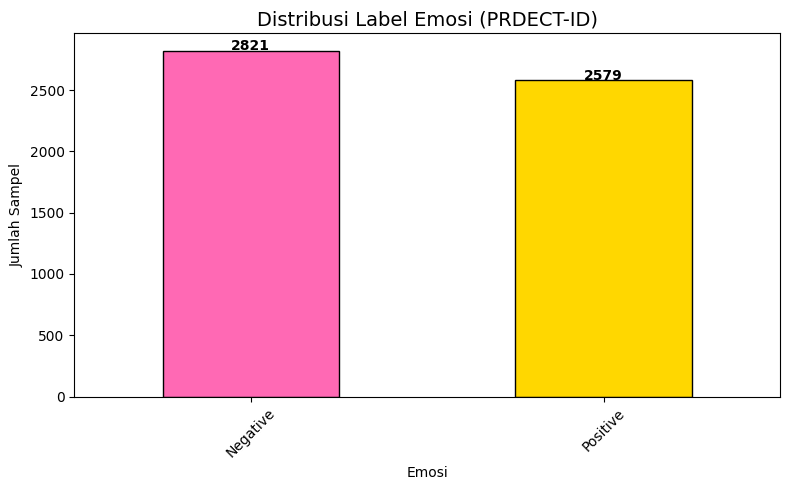

Plot saved.


In [6]:
## 5. EDA: Distribusi Label Emosi
print("=== Distribusi Emosi ===")
label_counts = df[LABEL_COL].value_counts()
print(label_counts)
print(f"\nTotal: {len(df)} sampel")

colors = ['#FF69B4', '#FFD700', '#FF4500', '#800080', '#4169E1']
fig, ax = plt.subplots(figsize=(8, 5))
label_counts.plot(kind='bar', ax=ax, color=colors[:len(label_counts)], edgecolor='black')
ax.set_title("Distribusi Label Emosi (PRDECT-ID)", fontsize=14)
ax.set_xlabel("Emosi")
ax.set_ylabel("Jumlah Sampel")
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / "label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

=== Statistik Panjang Teks ===
       text_length  word_count
count      5400.00     5400.00
mean        103.81       16.10
std          98.26       15.65
min           3.00        1.00
25%          44.00        7.00
50%          78.00       12.00
75%         128.00       20.00
max        1058.00      184.00


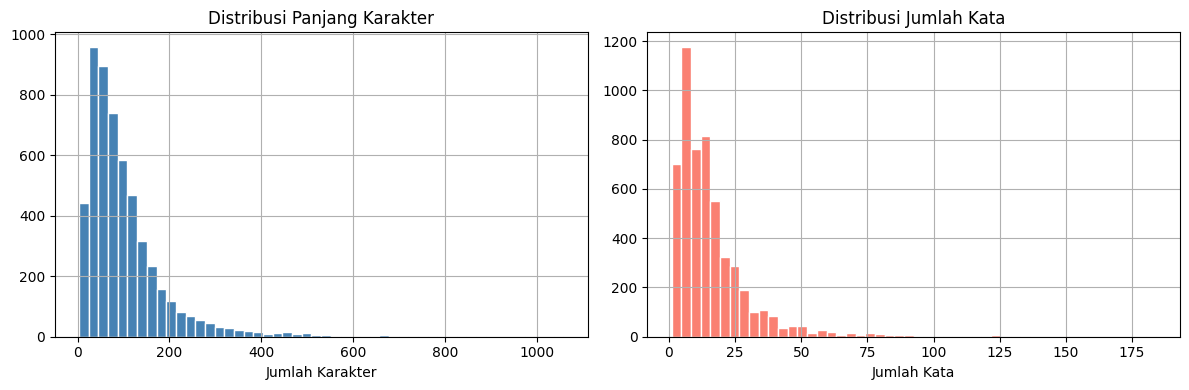

In [7]:
## 6. EDA: Statistik Panjang Teks
df['text_length'] = df[TEXT_COL].astype(str).apply(len)
df['word_count']  = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print("=== Statistik Panjang Teks ===")
print(df[['text_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['text_length'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Distribusi Panjang Karakter")
axes[0].set_xlabel("Jumlah Karakter")
df['word_count'].hist(bins=50, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title("Distribusi Jumlah Kata")
axes[1].set_xlabel("Jumlah Kata")
plt.tight_layout()
plt.show()

In [8]:
## 7. Text Cleaning
import emoji

# Slang Dictionary (Top 30-40 Indonesian Review Slang Words)
SLANG_MAP = {
    "yg": "yang",
    "ga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "ngga": "tidak",
    "nggak": "tidak",
    "bgt": "banget",
    "dgn": "dengan",
    "kalo": "kalau",
    "jgn": "jangan",
    "tp": "tapi",
    "sm": "sama",
    "sdh": "sudah",
    "krn": "karena",
    "utk": "untuk",
    "sy": "saya",
    "td": "tadi",
    "smg": "semoga",
    "blm": "belum",
    "jd": "jadi",
    "aja": "saja",
    "dah": "sudah",
    "udh": "sudah",
    "gw": "saya",
    "gua": "saya",
    "lu": "kamu",
    "elo": "kamu",
    "msh": "masih",
    "skrg": "sekarang",
    "dpt": "dapat",
    "dr": "dari",
    "km": "kamu",
    "pake": "pakai",
    "karna": "karena",
    "g": "tidak",
}

def clean_text(text: str) -> str:
    """Unicode normalisation, safe character cleaning, emoji demojizing, and slang normalization."""
    if not isinstance(text, str):
        return ""

    # 1. Unicode Normalization
    text = unicodedata.normalize('NFKC', text)

    # 2. Safe removal of corrupted character U+FFFD
    text = text.replace('\ufffd', ' ')

    # 3. Emoji Demojization (e.g. 😂 -> :face_with_tears_of_joy:)
    try:
        text = emoji.demojize(text)
    except Exception:
        pass

    text = text.lower()

    # 4. Remove URL and mentions
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@[\w_]+', ' ', text)

    # 5. Clean punctuation but preserve spaces, !?., and emoji delimiters (: and _)
    text = re.sub(r'[^a-zA-Z0-9\s!?.,:_]', ' ', text)

    # 6. Slang normalization (word-by-word replacement)
    words = text.split()
    normalized_words = []
    for w in words:
        clean_w = re.sub(r'[^a-zA-Z0-9]', '', w)
        if clean_w in SLANG_MAP:
            if w.startswith(':') and w.endswith(':'):
                normalized_words.append(w)  # Keep emoji text intact
            else:
                normalized_words.append(SLANG_MAP[clean_w])
        else:
            normalized_words.append(w)
    text = " ".join(normalized_words)

    # 7. Convert emoji text separators to spaces (e.g. :face_with_tears_of_joy: -> face with tears of joy)
    text = text.replace(':', ' ').replace('_', ' ')

    # 8. Clean up whitespace and repeated punctuation
    text = re.sub(r'([!?.,]){2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Contoh cleaning
sample_text = df[TEXT_COL].iloc[0]
print(f"Original : {repr(sample_text)}")
print(f"Cleaned  : {repr(clean_text(sample_text))}")

Original : 'Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah'
Cleaned  : 'alhamdulillah berfungsi dengan baik. packaging aman. respon cepat dan ramah. seller dan kurir amanah'


In [9]:
## 8. Apply Cleaning, Label Mapping & Deduplication
SENTIMENT_MAP = {
    'positive': 1,
    'negative': 0
}
ID2SENTIMENT = {v: k for k, v in SENTIMENT_MAP.items()}

# Raw row count for Table 2
len_raw = len(df)

# Normalize label (lowercase & strip)
df['emotion_label'] = df[LABEL_COL].str.lower().str.strip()

# Apply mapping
df['label'] = df['emotion_label'].map(SENTIMENT_MAP)
df = df.dropna(subset=['label'])

# --- 1. Audit Conflicting Labels (Sentiment Level) ---
duplicate_mask = df.duplicated(subset=[TEXT_COL], keep=False)
duplicates_df = df[duplicate_mask]

conflicting_texts = []
grouped_dupes = duplicates_df.groupby(TEXT_COL)
for text, group in grouped_dupes:
    if group['label'].nunique() > 1:
        conflicting_texts.append(text)

conflicting_df = duplicates_df[duplicates_df[TEXT_COL].isin(conflicting_texts)].copy()

# Save conflicting labels report for manual review (should find 0 conflicts for Sentiment)
reports_dir = Path("outputs/finetuning_indobert/reports")
reports_dir.mkdir(parents=True, exist_ok=True)
conflicting_out = reports_dir / "conflicting_labels.csv"
conflicting_df[[TEXT_COL, 'Sentiment', 'Customer Rating', 'Category']].to_csv(conflicting_out, index=False)
print(f"Saved conflicting labels report ({len(conflicting_df)} rows) to: {conflicting_out}")

# --- 2. Deduplicate (keep the first occurrence) ---
df = df.drop_duplicates(subset=[TEXT_COL], keep='first').copy()
len_dedup = len(df)

# --- 3. Apply Text Cleaning (PURE TEXT ONLY for XAI/LIME/SHAP mapping) ---
df['review_clean'] = df[TEXT_COL].apply(clean_text)

# Hapus baris kosong atau terlalu pendek
df = df.dropna(subset=['review_clean'])
df = df[df['review_clean'].str.strip().str.len() > 3]
len_clean = len(df)
df['label'] = df['label'].astype(int)

print("\n" + "="*60 + "\nTABEL AKADEMIK UNTUK LAPORAN SKRIPSI\n" + "="*60)

# --- TABEL 1: Sebelum vs Sesudah Pembersihan ---
print("\n### TABEL 1: CONTOH PEMBERSIHAN TEKS (BEFORE vs AFTER)")
sample_cleaning = df[[TEXT_COL, 'review_clean']].head(5)
print(sample_cleaning.to_markdown(index=False))
print("-" * 60)

# --- TABEL 2: Statistik Row Dataset (Sebelum vs Sesudah) ---
print("\n### TABEL 2: STATISTIK ROW DATASET (SEBELUM vs SESUDAH)")
stats = {
    "Tahapan Preprocessing": [
        "1. Dataset Mentah (Original Raw)", 
        "2. Setelah Deduplikasi (Deduplicated)", 
        "3. Setelah Filter Teks Pendek (Cleaned)"
    ],
    "Jumlah Baris": [len_raw, len_dedup, len_clean],
    "Baris Dibuang": [0, len_raw - len_dedup, len_dedup - len_clean]
}
print(pd.DataFrame(stats).to_markdown(index=False))
print("-" * 60)

# --- TABEL 3: Distribusi Kelas Sentimen Final ---
print("\n### TABEL 3: DISTRIBUSI SENTIMEN FINAL")
dist_df = df['emotion_label'].value_counts().reset_index()
dist_df.columns = ['Kelas Sentimen', 'Jumlah Ulasan']
dist_df['Persentase (%)'] = (dist_df['Jumlah Ulasan'] / len(df)) * 100
print(dist_df.to_markdown(index=False))
print("="*60)

Saved conflicting labels report (0 rows) to: outputs/finetuning_indobert/reports/conflicting_labels.csv

TABEL AKADEMIK UNTUK LAPORAN SKRIPSI

### TABEL 1: CONTOH PEMBERSIHAN TEKS (BEFORE vs AFTER)
| Customer Review                                                                                      | review_clean                                                                                         |
|:-----------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------|
| Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah | alhamdulillah berfungsi dengan baik. packaging aman. respon cepat dan ramah. seller dan kurir amanah |
| barang bagus dan respon cepat, harga bersaing dengan yg lain.                                        | barang bagus dan respon cepat, harga bersaing dengan yang lain.          

In [10]:
## 9. Stratified Split (80% Train / 20% Test) & Stratified K-Fold
# Split into Train and Test
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)

# Add Stratified 5-Fold split to the training set for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
df_train['fold'] = -1
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train['label'])):
    df_train.loc[df_train.index[val_idx], 'fold'] = fold_idx

print(f"Train size: {len(df_train)}")
print(f"Test size : {len(df_test)}")

print("\nFold distribution in Train:")
print(df_train.groupby(['fold', 'emotion_label']).size().unstack(fill_value=0))

Train size: 4243
Test size : 1061

Fold distribution in Train:
emotion_label  negative  positive
fold                             
0                   441       408
1                   440       409
2                   440       409
3                   440       408
4                   440       408


In [11]:
## 10. Export Data
import json

# Export cleaned full dataset
clean_out = PROC_DIR / "prdect_clean.csv"
df[['review_clean', 'emotion_label', 'label']].to_csv(clean_out, index=False)
print(f"Saved: {clean_out}")

# Export train/test split (including fold in train)
train_out = PROC_DIR / "prdect_train.csv"
test_out  = PROC_DIR / "prdect_test.csv"
df_train[['review_clean', 'emotion_label', 'label', 'fold']].to_csv(train_out, index=False)
df_test[['review_clean', 'emotion_label', 'label']].to_csv(test_out, index=False)
print(f"Saved: {train_out}")
print(f"Saved: {test_out}")

# Export label map
label_map_out = PROC_DIR / "prdect_label_map.json"
with open(label_map_out, 'w') as f:
    json.dump({"label2id": SENTIMENT_MAP, "id2label": ID2SENTIMENT}, f, indent=2)
print(f"Saved: {label_map_out}")

print("\n=== Summary ===")
print(f"Full dataset : {len(df)} rows")
print(f"Train set    : {len(df_train)} rows")
print(f"Test set     : {len(df_test)} rows")
print(f"Label mapping: {SENTIMENT_MAP}")

Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_clean.csv
Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_train.csv
Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_test.csv
Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_label_map.json

=== Summary ===
Full dataset : 5304 rows
Train set    : 4243 rows
Test set     : 1061 rows
Label mapping: {'positive': 1, 'negative': 0}
